In [1]:
# --- IMPORT LIBRARIES ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm

# --- LOAD DATASET ---
auto = pd.read_csv('Auto.csv')  # adjust path if needed
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


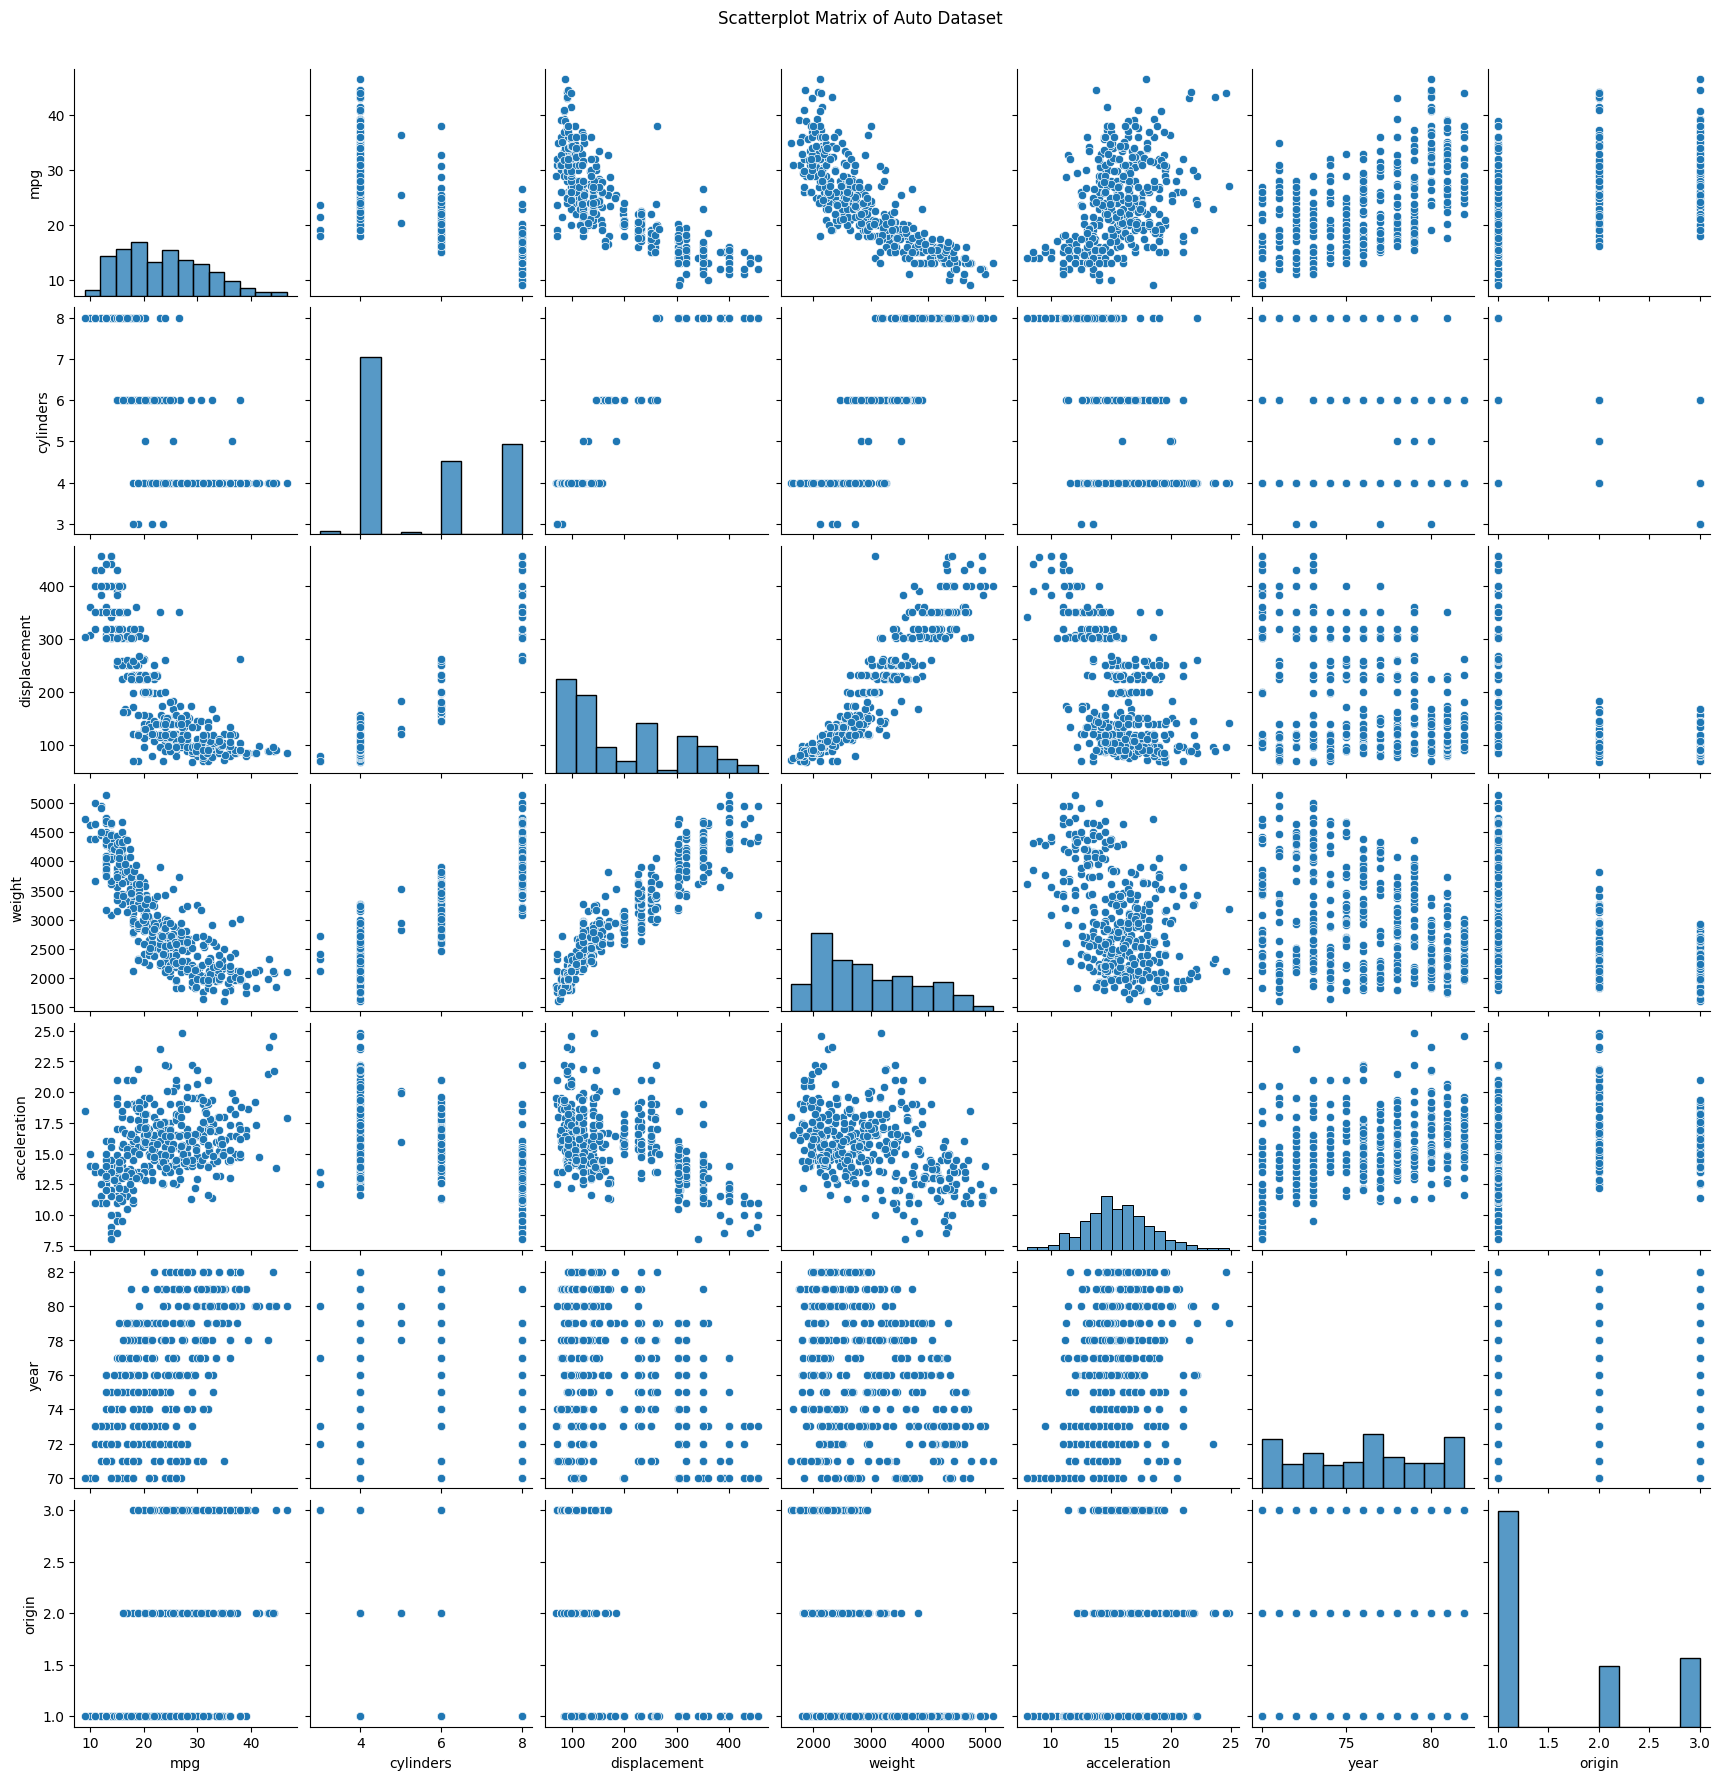

In [2]:
# Use seaborn pairplot
sns.pairplot(auto)
plt.suptitle('Scatterplot Matrix of Auto Dataset', y=1.02)
plt.show()

The scatterplot matrix shows pairwise relationships between all variables in the Auto dataset. It helps visualize linear trends, correlations, and potential outliers.

                   mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.777618     -0.805127   -0.778427 -0.832244   
cylinders    -0.777618   1.000000      0.950823    0.842983  0.897527   
displacement -0.805127   0.950823      1.000000    0.897257  0.932994   
horsepower   -0.778427   0.842983      0.897257    1.000000  0.864538   
weight       -0.832244   0.897527      0.932994    0.864538  1.000000   
acceleration  0.423329  -0.504683     -0.543800   -0.689196 -0.416839   
year          0.580541  -0.345647     -0.369855   -0.416361 -0.309120   
origin        0.565209  -0.568932     -0.614535   -0.455171 -0.585005   

              acceleration      year    origin  
mpg               0.423329  0.580541  0.565209  
cylinders        -0.504683 -0.345647 -0.568932  
displacement     -0.543800 -0.369855 -0.614535  
horsepower       -0.689196 -0.416361 -0.455171  
weight           -0.416839 -0.309120 -0.585005  
acceleration      1.000000  0.290316  0.212746  

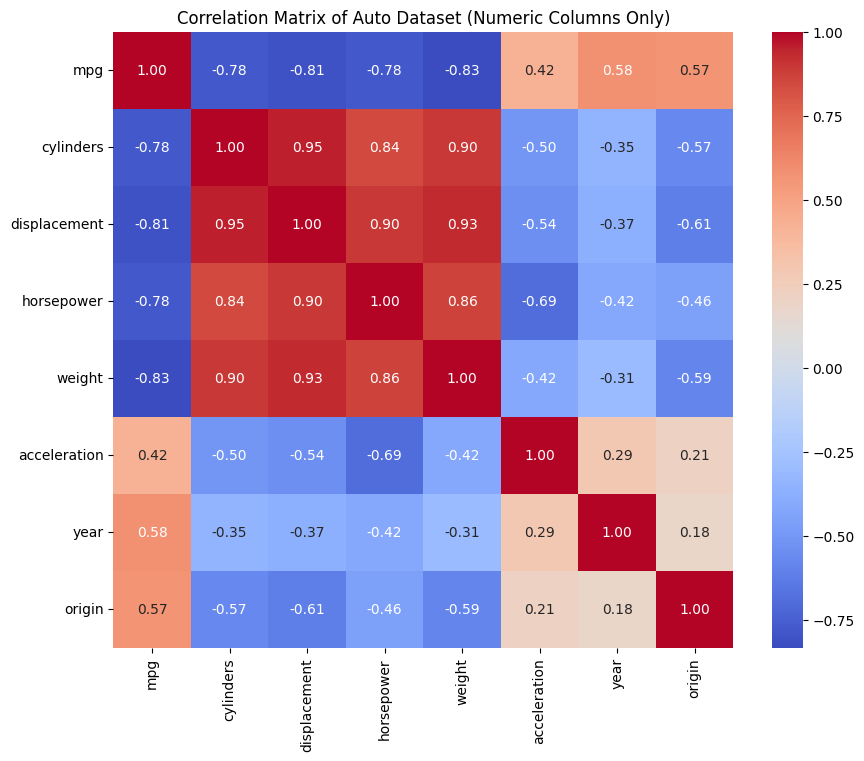

In [6]:
import numpy as np

# --- CLEAN DATA ---
# Replace '?' with NaN
auto = auto.replace('?', np.nan)

# Convert all columns except 'name' to numeric
for col in auto.columns:
    if col != 'name':
        auto[col] = pd.to_numeric(auto[col], errors='coerce')

# Drop rows with missing values
auto_clean = auto.dropna()

# --- COMPUTE CORRELATIONS (NUMERIC ONLY) ---
numeric_cols = auto_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
print(corr_matrix)

# Optional heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Auto Dataset (Numeric Columns Only)')
plt.show()

The correlation matrix quantifies the strength and direction of linear relationships between variables. Values close to 1 or -1 indicate strong positive or negative correlations, respectively.


In [7]:
# --- PREPARE PREDICTORS AND RESPONSE USING CLEAN DATA ---
X = auto_clean.drop(columns=['mpg', 'name'])  # exclude response & 'name'
y = auto_clean['mpg']

# Add constant term
X_const = sm.add_constant(X)

# Fit model
model_multi = sm.OLS(y, X_const).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Fri, 21 Nov 2025   Prob (F-statistic):          2.04e-139
Time:                        14:05:56   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2184      4.644     -3.707   

In [ ]:
This multiple linear regression model uses all predictors (except name) to explain mpg. The summary table shows coefficients, standard errors, t-values, and p-values for each predictor.
